In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
import h5py
import numpy as np
import tensorflow as tf
from sklearn.utils import shuffle
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, accuracy_score
import datetime
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns

# Function to load data
def load_data(
    path_prefix,
    dataset_name,
    splits=['train', 'test'],
):
    X, y = {}, {}

    IMG_SIZE = 224 if 'RAFDB' in dataset_name else 120
    splits = ['train', 'test'] if 'RAFDB' in dataset_name else splits
    classNames = ['anger', 'disgust', 'fear', 'happiness', 'neutral', 'sadness', 'surprise'] if 'RAFDB' in dataset_name else ['anger', 'contempt', 'disgust', 'fear', 'happiness', 'neutral', 'sadness', 'surprise']

    for split in splits:
        PATH = os.path.join(path_prefix, dataset_name, split)
        X[split], y[split] = [], []
        for classes in os.listdir(PATH):
            class_path = os.path.join(PATH, classes)
            class_numeric = classNames.index(classes)
            for sample in os.listdir(class_path):
                sample_path = os.path.join(class_path, sample)
                image = cv2.imread(sample_path, cv2.IMREAD_COLOR)
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
                X[split].append(image)
                y[split].append(class_numeric)

    # Convert to numpy arrays
    for split in splits:
        X[split] = np.array(X[split])
        y[split] = np.array(y[split])

    return X, y

# Load data from the RAFDB dataset
X, y = load_data('/content/drive/MyDrive/RAFDB_DATASET', dataset_name='RAFDB')

# Saving dataset to HDF5 file
with h5py.File('rafdb.h5', 'w') as dataset:
    for split in X.keys():
        dataset.create_dataset(f'X_{split}', data=X[split])
        dataset.create_dataset(f'y_{split}', data=y[split])

del X, y

In [ ]:
with h5py.File('rafdb.h5', 'r') as dataset:
    X_train = np.array(dataset['X_train'])
    y_train = np.array(dataset['y_train'])
    X_test = np.array(dataset['X_test'])
    y_test = np.array(dataset['y_test'])

# Shuffle the training data
X_train, y_train = shuffle(X_train, y_train)

# Print the shapes of the datasets
print("Shape of train_sample: {}".format(X_train.shape))
print("Shape of train_label: {}".format(y_train.shape))
print("Shape of test_sample: {}".format(X_test.shape))
print("Shape of test_label: {}".format(y_test.shape))

# Compute class weights for balanced training
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights))

Shape of train_sample: (12272, 224, 224, 3)
Shape of train_label: (12272,)
Shape of test_sample: (3068, 224, 224, 3)
Shape of test_label: (3068,)


Epoch 1/25
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 449s 321ms/step - accuracy: 0.5004 - loss: 1.5686 - val_accuracy: 0.5537 - val_loss: 1.2247 - learning_rate: 0.0010
Epoch 2/25
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 443s 321ms/step - accuracy: 0.6875 - loss: 1.0870 - val_accuracy: 0.7378 - val_loss: 0.8243 - learning_rate: 0.0010
Epoch 3/25
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 506s 324ms/step - accuracy: 0.7403 - loss: 0.9578 - val_accuracy: 0.6865 - val_loss: 0.9240 - learning_rate: 0.0010
Epoch 4/25
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 501s 323ms/step - accuracy: 0.7831 - loss: 0.8252 - val_accuracy: 0.7630 - val_loss: 0.7885 - learning_rate: 0.0010
Epoch 5/25
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 492s 316ms/step - accuracy: 0.7902 - loss: 0.7647 - val_accuracy: 0.7606 - val_loss: 0.7205 - learning_rate: 0.0010
Epoch 6/25
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 442s 316ms/step - accuracy: 0.8113 - loss: 0.6757 - val_accuracy: 0.7101 - val_loss: 0.9102 - learning_rate: 0.0010
Epoch 7/25
1381/1381 ━━━━━━━━━━━━━━━━━━━━ 445s 322ms

/usr/local/lib/python3.10/dist-packages/keras/src/ops/nn.py:545: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


96/96 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step


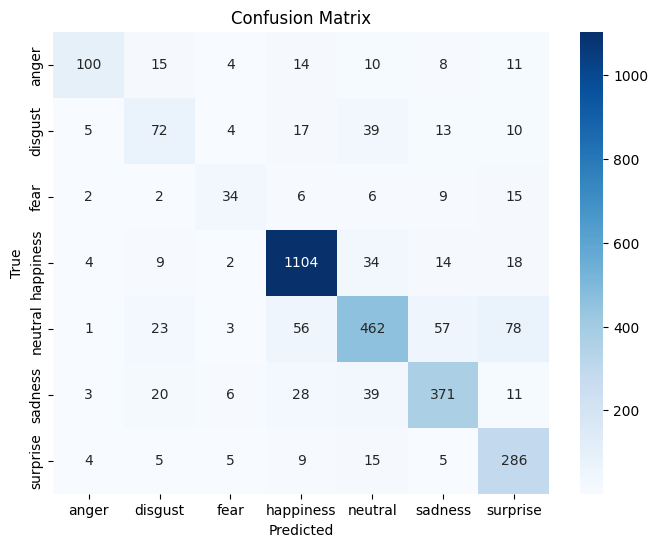

Accuracy: 0.7917


In [ ]:
# Model Building
from tensorflow.keras.layers import Resizing, RandomFlip, RandomContrast
input_layer = tf.keras.Input(shape=(224, 224, 3), name='universal_input')

# Preprocessing and augmentation
sample_resizing = tf.keras.layers.Resizing(224, 224, name="resize")
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(mode='horizontal'),
    tf.keras.layers.RandomContrast(factor=0.3)
], name="augmentation")
preprocess_input = tf.keras.applications.mobilenet.preprocess_input

# Feature extractor
backbone = tf.keras.applications.MobileNet(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
backbone.trainable = False
base_model = tf.keras.Model(backbone.input, backbone.layers[-29].output, name='base_model')

# Attention mechanism
self_attention = tf.keras.layers.Attention(use_scale=True, name='attention')

# Additional layers for feature extraction
patch_extraction = tf.keras.Sequential([
    tf.keras.layers.SeparableConv2D(256, kernel_size=5, strides=4, padding='same', activation='relu'),
    tf.keras.layers.SeparableConv2D(256, kernel_size=3, strides=2, padding='valid', activation='relu'),
    tf.keras.layers.Conv2D(256, kernel_size=1, strides=1, padding='valid', activation='relu')
], name='patch_extraction')
global_average_layer = tf.keras.layers.GlobalAveragePooling2D(name='gap')

# Pre-classification and classification layers
pre_classification = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.BatchNormalization()
], name='pre_classification')
prediction_layer = tf.keras.layers.Dense(7, activation="softmax", name='classification_head')  # 7 classes for RAFDB

# Model assembly
x = sample_resizing(input_layer)
x = data_augmentation(x)
x = preprocess_input(x)
x = base_model(x, training=False)
x = patch_extraction(x)
x = global_average_layer(x)
x = tf.keras.layers.Dropout(0.1)(x)
x = pre_classification(x)

# Reshape for Attention layer
x = tf.keras.layers.Reshape((-1, 32))(x)  # Ensure input to Attention is 3D
x = self_attention([x, x])  # Apply attention mechanism
x = tf.keras.layers.Flatten()(x)  # Flatten back to 2D for final layers

outputs = prediction_layer(x)
model = tf.keras.Model(input_layer, outputs, name='train-head')


# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3, global_clipnorm=3.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Training Procedure
early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=5, min_delta=0.003, restore_best_weights=True
)
learning_rate_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy', patience=3, verbose=0, min_delta=0.003, min_lr=1e-6
)

history = model.fit(
    X_train, y_train,
    epochs=25,
    batch_size=8,
    validation_split=0.1,
    verbose=1,
    class_weight=class_weights,
    callbacks=[early_stopping_callback, learning_rate_callback]
)

# Evaluate model on test data
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

# Predictions and confusion matrix
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[
    'anger', 'disgust', 'fear', 'happiness', 'neutral', 'sadness', 'surprise'
], yticklabels=[
    'anger', 'disgust', 'fear', 'happiness', 'neutral', 'sadness', 'surprise'
])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Accuracy Calculation
accuracy = accuracy_score(y_test, y_pred_classes)
print(f"Accuracy: {accuracy:.4f}")

# Save model
model.save('model_rafdb.h5')